In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('ai4i2020.csv')

Phase 1. Data integrity check

In [5]:
df.isnull() #check missing values

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
#impossible values

df[df["Torque [Nm]"] < 0]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


In [7]:
imposs = df[
    (df["Air temperature [K]"] < 180) | (df["Air temperature [K]"] > 330) |
    (df["Process temperature [K]"] < 0) | (df["Process temperature [K]"] > 1800)
]
print(imposs.to_string(index=False))

Empty DataFrame
Columns: [UDI, Product ID, Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], Machine failure, TWF, HDF, PWF, OSF, RNF]
Index: []


In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [9]:
#check for inconsistent failure flags
df[
    (df["Machine failure"] == 0) &
    (
        (df["TWF"] == 1) |
        (df["HDF"] == 1) |
        (df["PWF"] == 1) |
        (df["OSF"] == 1) |
        (df["RNF"] == 1)
    )
] #TWF, HDF, PWF, OSF, RNF when 1, Machine failure should be 1


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1
5495,5496,H34909,H,302.9,312.5,1357,55.0,12,0,0,0,0,0,1


Question: If this data feeds a real-time control system, what risks exist?

1.Invalid or out-of-range sensor values may cause incorrect real-time control actions.
2.Impossible air or process temperature readings can trigger false alarms or unnecessary machine shutdowns.
3.Incorrect failure flags may lead to avoidable production downtime and operational inefficiencies.
4.Missed or delayed failure detection increases the risk of equipment damage and accelerated wear.
5.Unstable control responses (speed, torque, temperature) may reduce machine reliability and lifespan.

Phase 2. Sensor behaviour analysis

In [10]:
#Analyze distributions of sensor readings
sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
df[sensor_columns].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


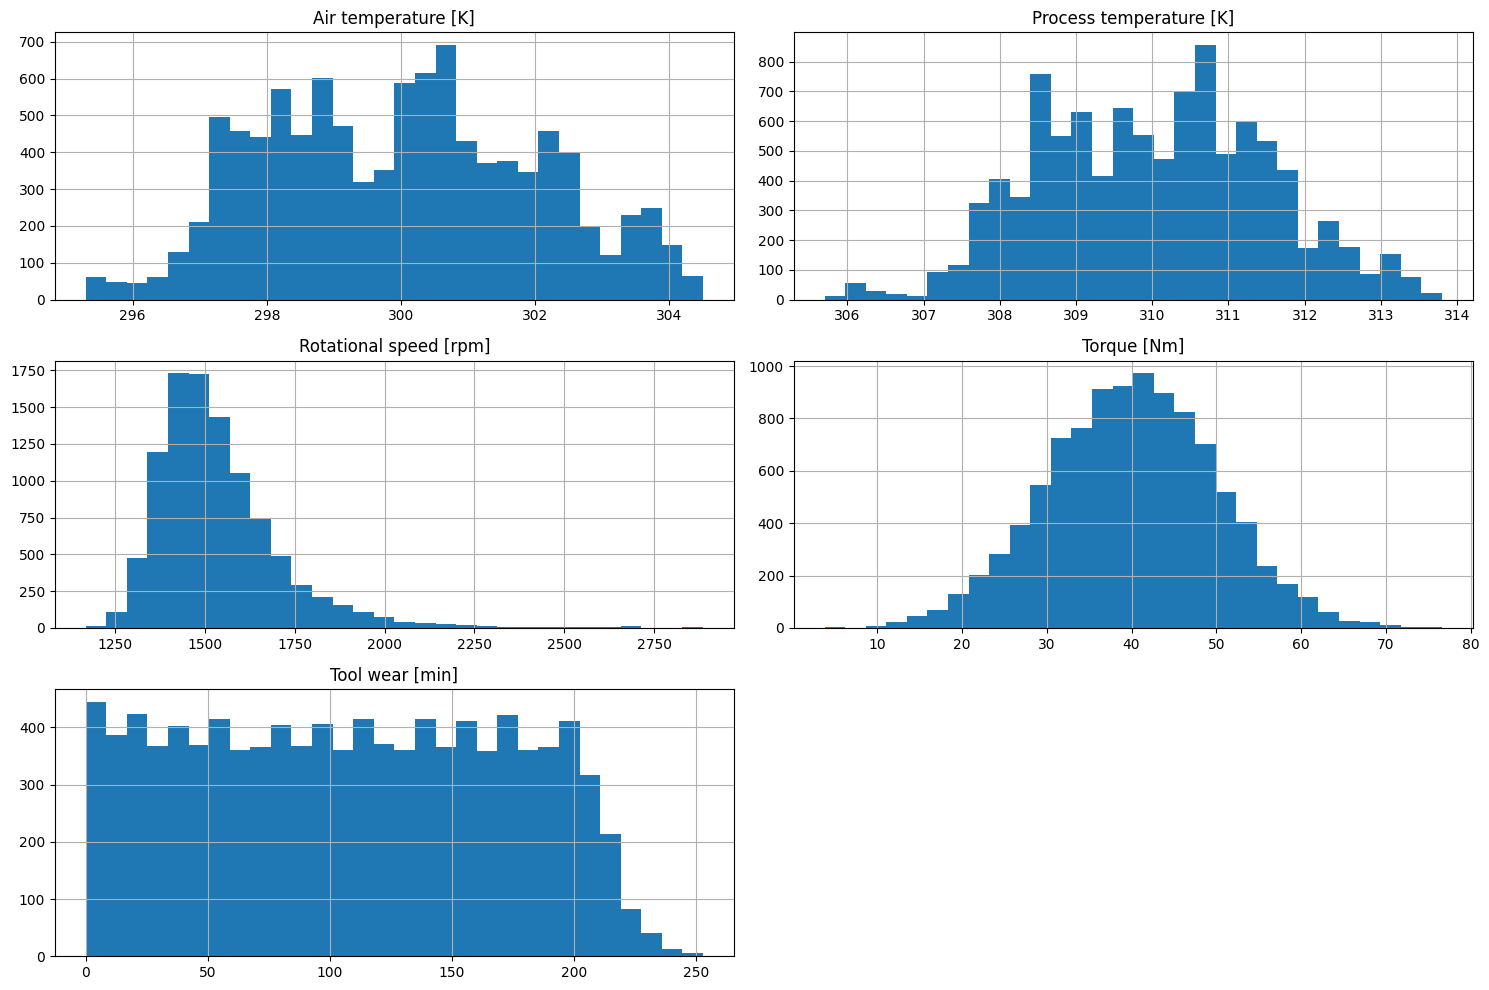

In [11]:
df[sensor_columns] .hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Air temperature and Process temprature plots have multiple peaks which means that there are different operating modes.
Rotational speed has a right-skewed plot and it indicates predominantly ominal operation with occasional high speed events. Torque plot is a bell-shaped, which means it's normally distributed, torque values show low dispersion around the mean, suggesting stable load conditions during normal machine operation. Tool wear plot  shows a heavy concentration at lower–mid values. Frequencies drop sharply at high wear values. The distribution is not symmetric.

In [13]:
#Compute dispersion
df[sensor_columns].std()

Air temperature [K]          2.000259
Process temperature [K]      1.483734
Rotational speed [rpm]     179.284096
Torque [Nm]                  9.968934
Tool wear [min]             63.654147
dtype: float64

In [14]:
#IQR
q1 = df[sensor_columns].quantile(0.25)
q3 = df[sensor_columns].quantile(0.75)
iqr = q3 - q1
print(iqr)

Air temperature [K]          3.2
Process temperature [K]      2.3
Rotational speed [rpm]     189.0
Torque [Nm]                 13.6
Tool wear [min]            109.0
dtype: float64


In [15]:
#extreme operating zones
low = df[sensor_columns].quantile(0.05)
high = df[sensor_columns].quantile(0.95)
extreme_zones = df[(df[sensor_columns] >= high) | (df[sensor_columns] <= low)]


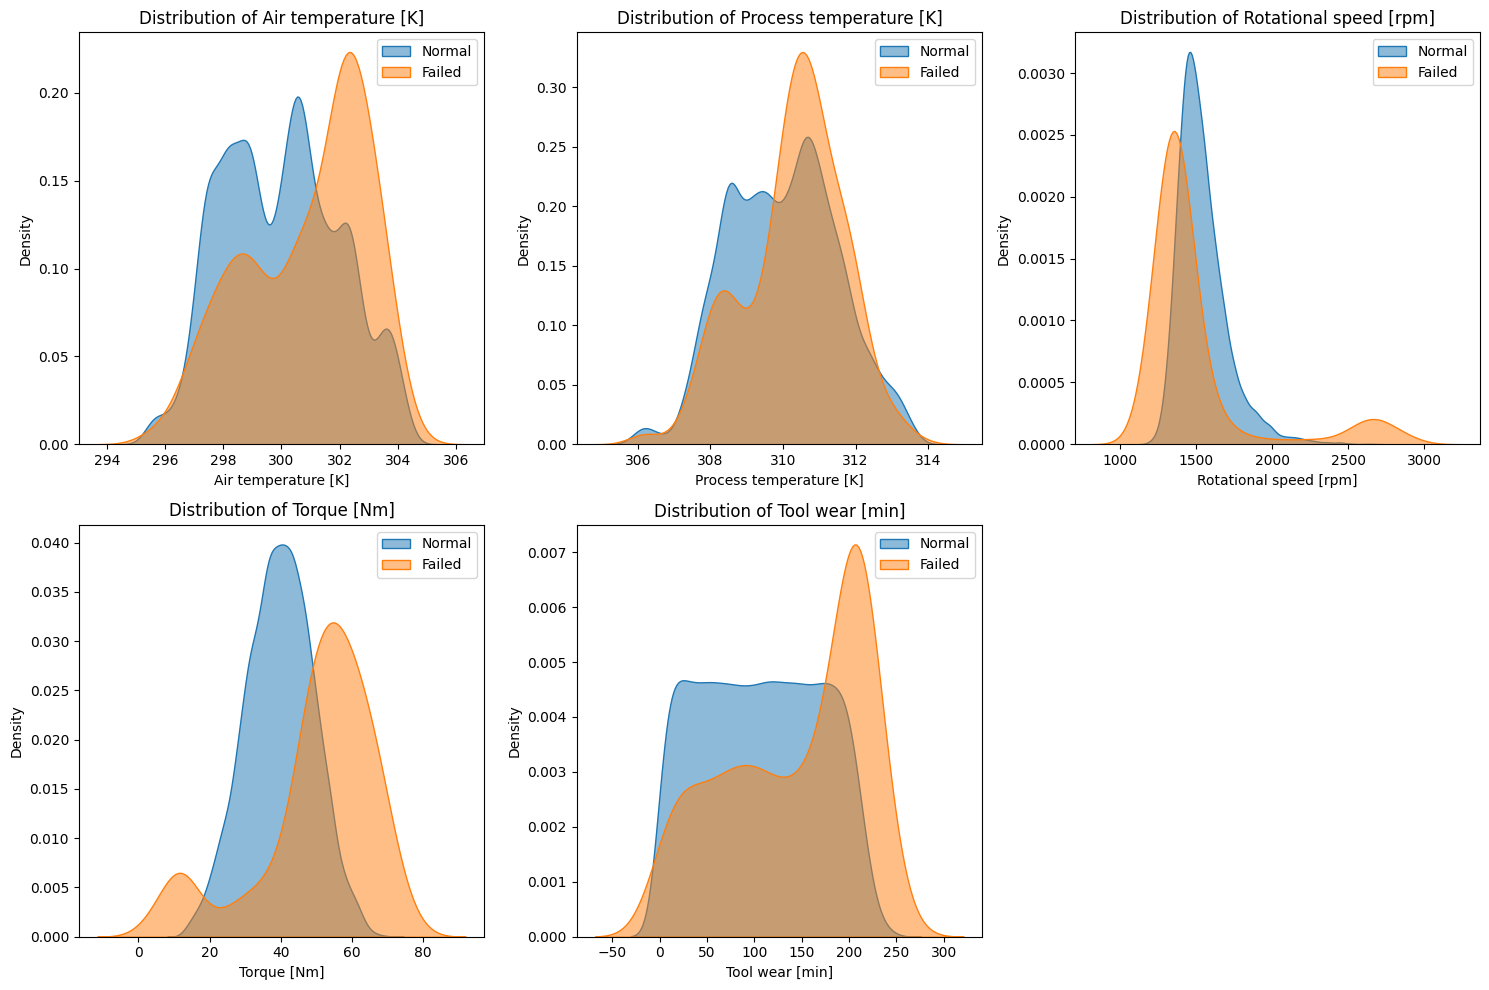

In [16]:
#comparing behaviour for normal and failed machines
failed_machines = df[df["Machine failure"] == 1]
normal_machines = df[df["Machine failure"] == 0]
plt.figure(figsize=(15, 10))
for i, column in enumerate(sensor_columns):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(normal_machines[column], label='Normal', fill=True, alpha=0.5)
    sns.kdeplot(failed_machines[column], label='Failed', fill=True, alpha=0.5)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout()

Comparison of sensor distributions between normal and failed machines shows that process temperature, torque, rotational speed, and tool wear exhibit significantly different behavior prior to failure. Failed machines tend to operate at higher temperatures, higher torque levels, and increased rotational speeds. Tool wear shows the strongest separation, with failures occurring predominantly at high wear values, indicating progressive degradation. Process temperature and torque also display gradual shifts, suggesting increasing thermal and mechanical stress before failure. These variables may therefore serve as early warning indicators, with tool wear being the most reliable predictor.

Phase 3.

In [17]:
#Z-score
from scipy import stats
z_scores = stats.zscore(df[sensor_columns])
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).any(axis=1)
outlier_data = df[outliers]
print(outlier_data)

       UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
50      51     L47230    L                298.9                    309.1   
194    195     M15054    M                298.2                    308.5   
298    299     H29712    H                297.9                    308.5   
305    306     L47485    L                297.8                    308.4   
344    345     M15204    M                297.5                    308.2   
...    ...        ...  ...                  ...                      ...   
9758  9759     L56938    L                298.6                    309.8   
9832  9833     L57012    L                298.4                    309.2   
9849  9850     L57029    L                298.6                    309.4   
9865  9866     M24725    M                298.9                    309.8   
9939  9940     H39353    H                298.3                    308.1   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
50      

In [18]:
#iqr
q1 = df[sensor_columns].quantile(0.25)
q3 = df[sensor_columns].quantile(0.75)          
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_iqr = df[
    (df[sensor_columns] < lower_bound) | (df[sensor_columns] > upper_bound)
]
print(outlier_iqr)

      UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0     NaN        NaN  NaN                  NaN                      NaN   
1     NaN        NaN  NaN                  NaN                      NaN   
2     NaN        NaN  NaN                  NaN                      NaN   
3     NaN        NaN  NaN                  NaN                      NaN   
4     NaN        NaN  NaN                  NaN                      NaN   
...   ...        ...  ...                  ...                      ...   
9995  NaN        NaN  NaN                  NaN                      NaN   
9996  NaN        NaN  NaN                  NaN                      NaN   
9997  NaN        NaN  NaN                  NaN                      NaN   
9998  NaN        NaN  NaN                  NaN                      NaN   
9999  NaN        NaN  NaN                  NaN                      NaN   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
0                   

In [21]:
for col in sensor_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    anomaly_flag = ((df[col] < lower) | (df[col] > upper))
    
    print(f"\n{col}")
    print(pd.crosstab(anomaly_flag, df["Machine failure"]))



Air temperature [K]
Machine failure         0    1
Air temperature [K]           
False                9661  339

Process temperature [K]
Machine failure             0    1
Process temperature [K]           
False                    9661  339

Rotational speed [rpm]
Machine failure            0    1
Rotational speed [rpm]           
False                   9278  304
True                     383   35

Torque [Nm]
Machine failure     0    1
Torque [Nm]               
False            9654  277
True                7   62

Tool wear [min]
Machine failure     0    1
Tool wear [min]           
False            9661  339


In this industrial dataset, anomalous observations are more appropriately interpreted as early indicators of breakdown rather than noise. Many anomalies correspond to extreme operating conditions and show increased overlap with machine failure events. Removing such records would reduce the model’s ability to detect high-risk states. Instead, anomalies should be flagged and incorporated as risk indicators to support early warning and preventive maintenance.

Phase 4

In [24]:
df["Temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
bins = [-float("inf"), 10, 25, float("inf")]
labels = ["Stable", "Warning", "Overheating Risk"]

df["Temp_diff_risk"] = pd.cut(
    df["Temp_diff"],
    bins=bins,
    labels=labels
)
print(df["Temp_diff_risk"].value_counts())


Temp_diff_risk
Stable              5537
Warning             4463
Overheating Risk       0
Name: count, dtype: int64


In [23]:
bins = [0, 100, 200, float("inf")]
labels = ["Normal", "Maintenance Soon", "Critical"]

df["Tool_wear_risk"] = pd.cut(
    df["Tool wear [min]"],
    bins=bins,
    labels=labels,
    right=False
)
df[["Temp_diff_risk", "Tool_wear_risk", "Machine failure"]].head(10)

,Temp_diff_risk,Tool_wear_risk,Machine failure
0,Warning,Normal,0
1,Warning,Normal,0
2,Warning,Normal,0
3,Warning,Normal,0
4,Warning,Normal,0
5,Warning,Normal,0
6,Warning,Normal,0
7,Warning,Normal,0
8,Warning,Normal,0
9,Warning,Normal,0


In [25]:
bins = [-float("inf"), 40, 60, float("inf")]
labels = ["Normal Load", "High Load", "Overload Risk"]

df["Torque_risk"] = pd.cut(
    df["Torque [Nm]"],
    bins=bins,
    labels=labels
)
df[["Torque_risk", "Machine failure"]].head(10)

,Torque_risk,Machine failure
0,High Load,0
1,High Load,0
2,High Load,0
3,Normal Load,0
4,Normal Load,0
5,High Load,0
6,High Load,0
7,High Load,0
8,Normal Load,0
9,Normal Load,0


In [26]:
bins = [-float("inf"), 1500, 2500, float("inf")]
labels = ["Normal Speed", "High Speed", "Stress Zone"]

df["Speed_risk"] = pd.cut(
    df["Rotational speed [rpm]"],
    bins=bins,
    labels=labels
)
df[["Speed_risk", "Machine failure"]].head(10)

,Speed_risk,Machine failure
0,High Speed,0
1,Normal Speed,0
2,Normal Speed,0
3,Normal Speed,0
4,Normal Speed,0
5,Normal Speed,0
6,High Speed,0
7,High Speed,0
8,High Speed,0
9,High Speed,0


In [27]:
pd.crosstab(df["Temp_diff_risk"], df["Machine failure"])


Machine failure,0,1
Temp_diff_risk,,
Stable,5302,235
Warning,4359,104


In [29]:
risk_columns = [
    "Temp_diff_risk",
    "Tool_wear_risk",
    "Torque_risk",
    "Speed_risk"
]

for col in risk_columns:
    print(f"\nFailure rate by {col}")
    print(
        df.groupby(col)["Machine failure"]
          .mean()
          .rename("Failure rate")
    )



Failure rate by Temp_diff_risk
Temp_diff_risk
Stable     0.042442
Warning    0.023303
Name: Failure rate, dtype: float64

Failure rate by Tool_wear_risk
Tool_wear_risk
Normal              0.022294
Maintenance Soon    0.024678
Critical            0.153558
Name: Failure rate, dtype: float64

Failure rate by Torque_risk
Torque_risk
Normal Load      0.012432
High Load        0.037262
Overload Risk    0.419492
Name: Failure rate, dtype: float64

Failure rate by Speed_risk
Speed_risk
Normal Speed    0.056435
High Speed      0.006942
Stress Zone     0.812500
Name: Failure rate, dtype: float64


In [30]:
risk_summary = df.groupby("Temp_diff_risk").agg(
    Failure_rate=("Machine failure", "mean"),
    Count=("Machine failure", "count")
).reset_index()


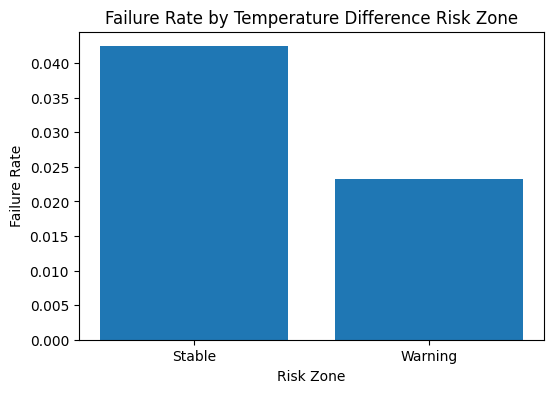

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    risk_summary["Temp_diff_risk"],
    risk_summary["Failure_rate"]
)

plt.xlabel("Risk Zone")
plt.ylabel("Failure Rate")
plt.title("Failure Rate by Temperature Difference Risk Zone")
plt.show()


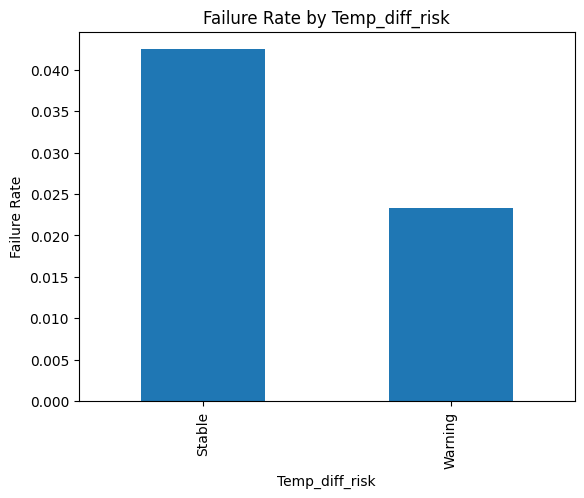

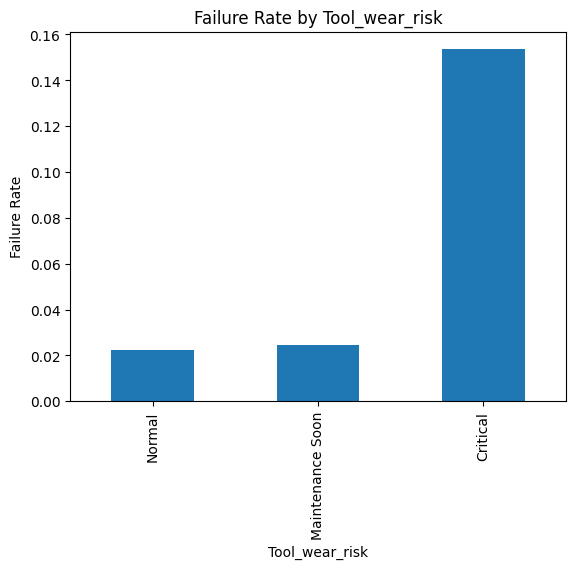

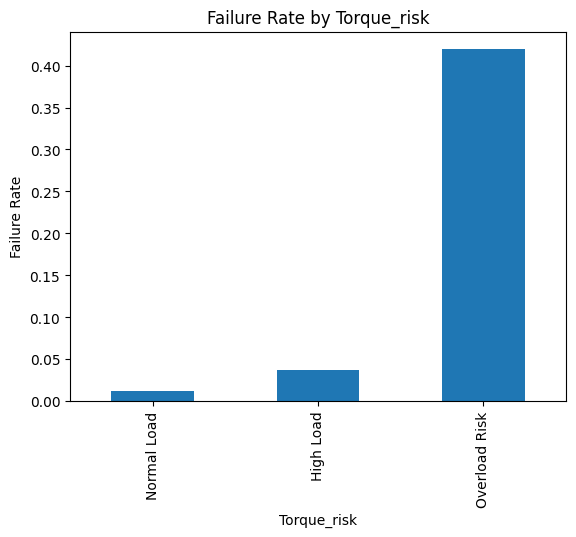

In [32]:
risk_cols = ["Temp_diff_risk", "Tool_wear_risk", "Torque_risk"]

for col in risk_cols:
    summary = df.groupby(col)["Machine failure"].mean()
    summary.plot(kind="bar", title=f"Failure Rate by {col}")
    plt.ylabel("Failure Rate")
    plt.show()


Risk segmentation meaningfully separates failure probability, as failure rates increase consistently across risk zones. This trend confirms that the defined thresholds capture progressively higher operational risk.

Phase 5

In [39]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df[sensor_columns])
df_scaled = pd.DataFrame(
    df_scaled,
    columns=sensor_columns,
    index=df.index
)
print(df_scaled.head())


   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0             -0.62500                -0.652174                0.253968   
1             -0.59375                -0.608696               -0.502646   
2             -0.62500                -0.695652               -0.026455   
3             -0.59375                -0.652174               -0.370370   
4             -0.59375                -0.608696               -0.502646   

   Torque [Nm]  Tool wear [min]  
0     0.198529        -0.990826  
1     0.455882        -0.963303  
2     0.683824        -0.944954  
3    -0.044118        -0.926606  
4    -0.007353        -0.908257  


In [41]:
df["Machine failure"].value_counts()
df["Machine failure"].value_counts(normalize=True)


Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [42]:
class_summary = df["Machine failure"].value_counts().reset_index()
class_summary.columns = ["Class", "Count"]

class_summary["Percentage"] = (
    class_summary["Count"] / class_summary["Count"].sum() * 100
)

print(class_summary)


   Class  Count  Percentage
0      0   9661       96.61
1      1    339        3.39


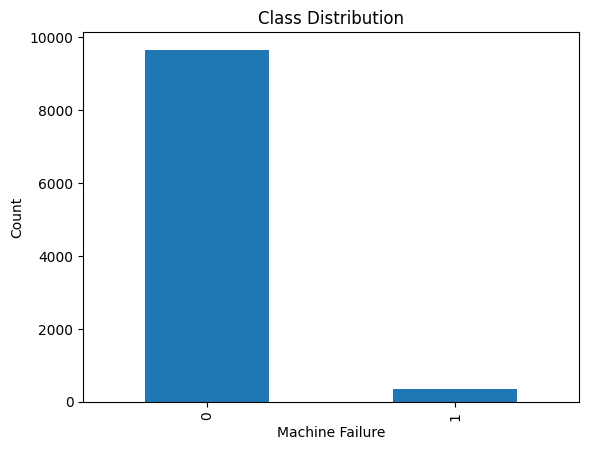

In [43]:
import matplotlib.pyplot as plt

df["Machine failure"].value_counts().plot(kind="bar")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()


In [45]:
from sklearn.model_selection import train_test_split

df_sampled, _ = train_test_split(
    df,
    test_size=0.7,            
    stratify=df["Machine failure"],
    random_state=42
)
df["Machine failure"].value_counts(normalize=True)
df_sampled["Machine failure"].value_counts(normalize=True)



Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64

In [46]:
full_stats = df[sensor_columns].describe().T
sample_stats = df_sampled[sensor_columns].describe().T

comparison = full_stats[["mean", "std", "min", "max"]].join(
    sample_stats[["mean", "std", "min", "max"]],
    lsuffix="_full",
    rsuffix="_sample"
)

print(comparison)


                          mean_full    std_full  min_full  max_full  \
Air temperature [K]       300.00493    2.000259     295.3     304.5   
Process temperature [K]   310.00556    1.483734     305.7     313.8   
Rotational speed [rpm]   1538.77610  179.284096    1168.0    2886.0   
Torque [Nm]                39.98691    9.968934       3.8      76.6   
Tool wear [min]           107.95100   63.654147       0.0     253.0   

                         mean_sample  std_sample  min_sample  max_sample  
Air temperature [K]       300.029533    2.000209       295.5       304.5  
Process temperature [K]   310.023467    1.465971       305.9       313.8  
Rotational speed [rpm]   1537.619000  180.216410      1168.0      2886.0  
Torque [Nm]                40.040200    9.929227         3.8        75.4  
Tool wear [min]           107.250333   63.734070         0.0       244.0  


In [47]:
comparison["mean_diff_%"] = (
    (comparison["mean_sample"] - comparison["mean_full"])
    / comparison["mean_full"] * 100
)

comparison["std_diff_%"] = (
    (comparison["std_sample"] - comparison["std_full"])
    / comparison["std_full"] * 100
)

print(comparison[["mean_diff_%", "std_diff_%"]])


                         mean_diff_%  std_diff_%
Air temperature [K]         0.008201   -0.002500
Process temperature [K]     0.005776   -1.197165
Rotational speed [rpm]     -0.075196    0.520021
Torque [Nm]                 0.133269   -0.398302
Tool wear [min]            -0.649060    0.125559


In [48]:
failure_full = df["Machine failure"].mean()
failure_sample = df_sampled["Machine failure"].mean()

print("Failure rate (full):", failure_full)
print("Failure rate (sample):", failure_sample)


Failure rate (full): 0.0339
Failure rate (sample): 0.034


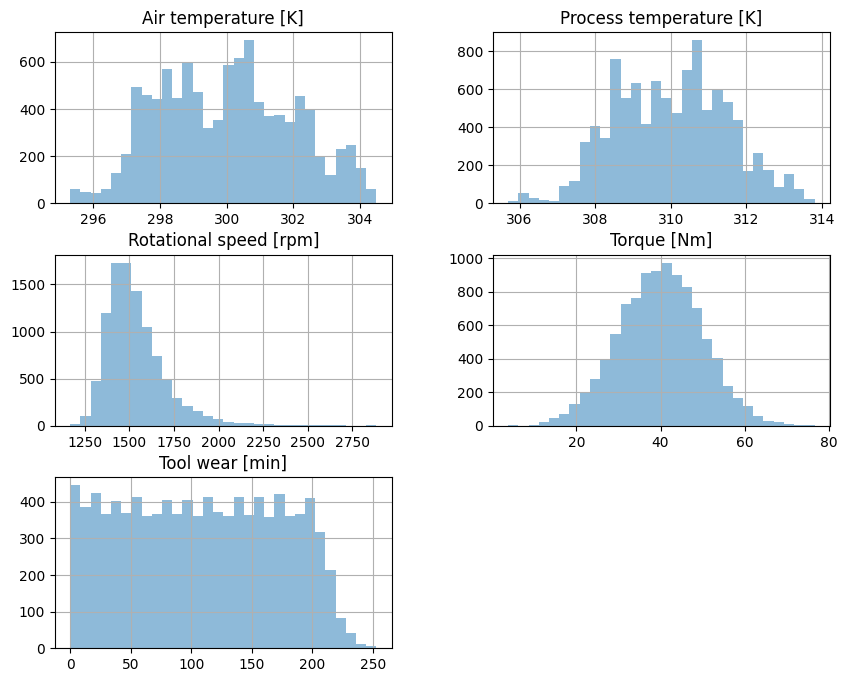

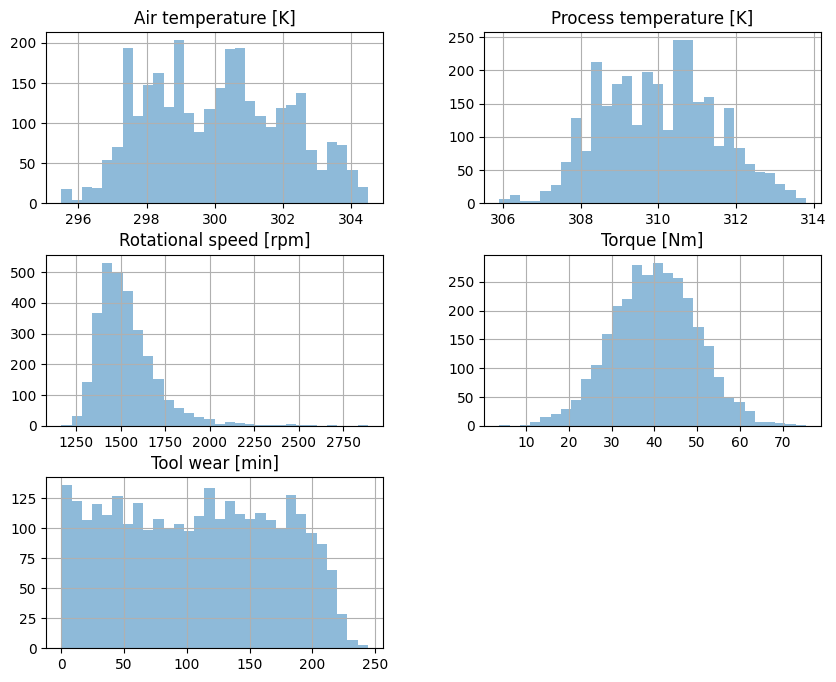

In [49]:
df[sensor_columns].hist(bins=30, alpha=0.5, figsize=(10,8))
df_sampled[sensor_columns].hist(bins=30, alpha=0.5, figsize=(10,8))
plt.show()


If this dataset is used for model training, several sources of bias may affect model performance and reliability. Failure events are relatively rare compared to normal operation, creating class imbalance that can bias the model toward predicting non-failure states and reduce its ability to detect failures. The presence of multiple operating regimes may cause the model to learn patterns dominated by common conditions while underperforming in less frequent but higher-risk operating modes. Some sensor variables provide weak or noisy signals, which can dilute stronger predictors and introduce measurement bias. In addition, failure labels are derived from predefined mechanisms, potentially limiting the model’s ability to generalize to unseen or novel failure types. Finally, the lack of explicit temporal context may bias the model toward recognizing failures at the point of occurrence rather than learning early warning patterns.